In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"     # agama
os.environ["MKL_NUM_THREADS"] = "1"     # numpy, scipy
os.environ["OPENBLAS_NUM_THREADS"] = "1"    # numpy
os.environ["NUMEXPR_NUM_THREADS"] = "1"     # pandas

import agama
import torch 
import numpy as np
from scipy import integrate
# from scipy.stats import wasserstein_distance_nd
from astropy import units as u

from sbi.utils import BoxUniform

from sbi.inference import SNLE, simulate_for_sbi, prepare_for_sbi


from sbi.utils import likelihood_nn

from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
import pickle
import matplotlib.pyplot as plt
from galaxy_generation import generate_galaxy_multiple, transform_params
from prior_generation import generate_prior
from standardization import standardize
from object_handler import load_csv, load_pickle, save_csv

from model import prep_data

# from wasserstein_distance_nd import wasserstein_distance_nd 
import corner

torch.set_num_threads(4)


In [18]:
train_theta="./model_1/train_theta.csv"
train_x = "./model_1/train_x.csv"
t, x = prep_data(train_theta, train_x, standardization=True)

In [21]:
x.shape

AttributeError: 'tuple' object has no attribute 'shape'

In [3]:
def density(x: np.ndarray, 
            theta: torch.Tensor) -> np.ndarray:
    """
    Calculate density using GNFW profile as a function of r
    
    Params:
    - x: the value at which the function must be computed at (log_r_div_rstar)
    - theta: MCMC samples of the posterior
    """
    theta = np.array(transform_params(theta))
    
    alpha = theta[:,0]
    beta = theta[:,1]
    gamma = theta[:,2]
    p_0 = theta[:,3]
    r_s = theta[:,4]
    r_star = theta[:,5]
    
    r = 10 ** x * r_star

    rho = p_0 * (r / r_s) ** -gamma * (1 + (r / r_s) ** alpha) ** (-(beta-gamma)/alpha)
    
    return np.log10(rho)

In [8]:
cored_params = load_csv("mass_density_samples_model_14_core.csv", "Tensor")


In [11]:
(cored_params[:,1] + cored_params[:,0]).T


/tmp/ipykernel_1519478/3037505097.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /croot/pytorch-select_1717607455294/work/aten/src/ATen/native/TensorShape.cpp:3675.)
  (cored_params[:,1] + cored_params[:,0]).T


tensor([6.8871, 6.8602, 6.9556,  ..., 7.3751, 7.3311, 7.5828])

In [12]:
np.quantile(cored_params, [0.1,0.2], axis=0)

array([[ 7.19623461, -0.40459775, -0.86520606,  0.22706032],
       [ 7.34835968, -0.34937022, -0.74839115,  0.25332154]])

In [51]:
test_theta_raw = load_csv("model_1/test_theta.csv", "Tensor")
test_x_raw = load_csv("model_1/test_x.csv", "Tensor")

In [4]:
from mcmc import prep_posterior
# MCMC settings
mcmc_settings = {"mcmc_method":"slice_np_vectorized", 
                "mcmc_parameters":{"warmup_steps":500,
                            "num_chains":8,
                            "num_workers": 1,
                            "init_strategy": "sir",
                            "thin": 1}}
                                    
                                    
# Example code for mass density
prof = "core"

test_x = prep_data(f"./model_1/mass_density_{prof}.csv",
                    train_x= "./model_1/train_x.csv")

posterior = prep_posterior(f"./model_1/inference.pkl",
                            mcmc_settings)

In [9]:
inference = load_pickle("./model_1/inference.pkl")

In [36]:
x_o = load_csv("./model_1/mass_density_core.csv", "Tensor")
# x = standardize(load_csv("./model_1/train_x.csv", "Tensor"))
# x_o = (x_o - x[1]) / x[2]

In [38]:
a = load_csv("./model_1/test_x.csv", "Tensor")

In [3]:
a = generate_galaxy_multiple(torch.tensor([[1.0, 3.0, 1.0, 8.0755, 0.0, -0.6402, 0.0, 0.0]]), [100], 1)

In [11]:
save_csv(a, "./model_1/mass_density_cusp.csv")

In [6]:
pd.DataFrame(a)

,0,1,2
0,-0.076909,-0.208668,-7.273375
1,-0.170446,-0.003347,-7.750532
2,-0.067974,-0.352631,0.091074
3,0.416837,0.408487,-6.916947
4,0.273731,0.213345,6.219764
...,...,...,...
95,0.390175,-0.198657,8.959859
96,0.219366,0.304440,13.528080
97,-0.146010,0.109319,-23.311890
98,0.534421,-0.674116,-0.352211


In [33]:
test_x[0]

tensor([[ 4.0378e+07,  3.6423e+07, -3.0644e+04],
        [ 7.8551e+07,  1.7394e+08,  1.1569e+05],
        [-2.3991e+07, -2.0981e+07, -3.5483e+05],
        [ 2.8458e+07, -1.2612e+08,  7.5697e+04],
        [-3.0668e+07,  4.8108e+05,  2.2733e+05],
        [ 2.0385e+07,  8.2241e+07, -9.7879e+04],
        [-1.3269e+08,  7.4777e+07, -1.1015e+04],
        [-4.2933e+06, -1.9062e+07, -8.3158e+04],
        [-9.5872e+06, -2.0243e+07,  1.9554e+05],
        [ 1.0698e+08,  4.0181e+07, -4.1277e+04],
        [ 7.5410e+07, -6.8111e+06, -1.1958e+05],
        [ 1.1055e+08, -5.4752e+07, -1.4366e+05],
        [-1.3568e+07, -4.4250e+07, -1.2979e+05],
        [ 8.3119e+06,  1.8262e+07, -1.5663e+05],
        [-3.1800e+08, -2.8462e+08, -2.0026e+05],
        [-1.3405e+08,  5.4298e+07,  1.3522e+05],
        [-6.7233e+07, -7.3193e+07,  3.0398e+04],
        [ 3.8944e+07,  3.4641e+06, -1.7045e+05],
        [-7.2630e+08,  4.1886e+08, -5.6452e+03],
        [ 8.9037e+07,  4.9056e+07, -6.0304e+04],
        [ 2.8475e+07

In [ ]:
x_o = test_x[0] 
# x = standardize(load_csv("./model_1/train_x.csv", "Tensor"))
# x_o = (x_o - x[1]) / x[2]

# 2. Define your parameter vector (ensure it is float)
theta = torch.tensor([[1.0, 3.0, 0.0, 8.0755, 0.0, -0.6402, 0.0, 0.0]])

# 3. Repeat the parameters so there is 1 parameter vector for every star
theta_repeated = theta.repeat(x_o.shape[0], 1)

# 4. Correctly evaluate the log-probability: p(stars | parameters)
log_probs = inference._neural_net.log_prob(inputs=x_o, context=theta_repeated)

In [32]:
log_probs.sum()

tensor(-2.1555e+15, grad_fn=<SumBackward0>)

In [2]:
a = load_pickle("./model_1/tune_r2.pkl")

In [9]:
a.trials[91]

FrozenTrial(number=91, state=<TrialState.COMPLETE: 1>, values=[9.702755182217329], datetime_start=datetime.datetime(2026, 7, 7, 2, 59, 45, 895003), datetime_complete=datetime.datetime(2026, 7, 7, 3, 33, 32, 370629), params={'learning_rate': 0.0019069978413174835, 'model': 'nsf', 'hidden_features': 126, 'num_transforms': 8, 'num_bins': 8}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'learning_rate': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'model': CategoricalDistribution(choices=('maf', 'nsf')), 'hidden_features': IntDistribution(high=128, log=False, low=32, step=1), 'num_transforms': IntDistribution(high=8, log=False, low=3, step=1), 'num_bins': IntDistribution(high=12, log=False, low=4, step=1)}, trial_id=91, value=None)

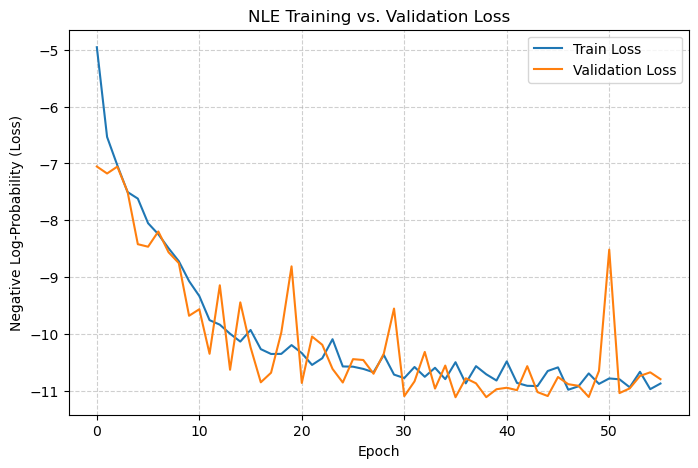

In [12]:
df = load_csv("./model_1/train_theta.csv", "ndarray")

In [13]:
_, i = np.unique(df, axis=0, return_index=True)

In [14]:
index = np.sort(i)

In [ ]:
new_df = df[index]

In [31]:
num = np.diff(np.concatenate((index, np.array([df.shape[0]]))))
a = np.column_stack((new_df,num))

In [32]:
theta, k = a[:,:-1], a[:,-1]

In [ ]:
torch.repeat_interleave(theta, )

array([109., 103., 104., ..., 119., 124., 104.])